In [5]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
%pip install seaborn
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


# Import from Kaggle the dataset.

In [6]:
%pip install kagglehub
import kagglehub
import os

# Import from kaggle
path = kagglehub.dataset_download("ishans24/brain-tumor-dataset")
print("Dataset path:", path)
print(os.listdir(path))

Note: you may need to restart the kernel to use updated packages.


 24%|██▍       | 207M/862M [00:15<00:49, 13.9MB/s] 


KeyboardInterrupt: 

In [ ]:
# no training / testing folders so there a little more work that needs to be done
root_path = path

# Train / validation split of files 80/20

In [ ]:
img_size = (224, 224)
batch_size = 32
# need to create Training
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    root_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="training"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    root_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="validation"
)

Found 10560 files belonging to 4 classes.
Using 8448 files for training.
Found 10560 files belonging to 4 classes.
Using 2112 files for validation.


In [ ]:
num_classes = 4

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=img_size + (3,)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    dataset,
    validation_data=val_ds,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 40s 125ms/step - accuracy: 0.6444 - loss: 0.9644 - val_accuracy: 0.8537 - val_loss: 0.3633
Epoch 2/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 32s 121ms/step - accuracy: 0.8622 - loss: 0.3474 - val_accuracy: 0.9025 - val_loss: 0.2628
Epoch 3/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - accuracy: 0.9306 - loss: 0.1832 - val_accuracy: 0.9110 - val_loss: 0.2470
Epoch 4/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 32s 120ms/step - accuracy: 0.9607 - loss: 0.1136 - val_accuracy: 0.9219 - val_loss: 0.2635
Epoch 5/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 49s 152ms/step - accuracy: 0.9771 - loss: 0.0700 - val_accuracy: 0.9110 - val_loss: 0.2969
Epoch 6/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 32s 117ms/step - accuracy: 0.9793 - loss: 0.0603 - val_accuracy: 0.9209 - val_loss: 0.3082
Epoch 7/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 32s 120ms/step - accuracy: 0.9871 - loss: 0.0398 - val_accuracy: 0.9512 - val_loss: 0.2074
Epoch 8/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 36s 135ms/step - accuracy: 0.9890 - loss: 0

# Get Predictions on Validatoin

In [ ]:
# Lists to store the true labels and predicted labels
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)  # Use the trained model to predict the class probabilities for the batch
    y_pred.extend(np.argmax(preds, axis=1))  # Convert probabilities → predicted class index (0,1,2,3)
    y_true.extend(np.argmax(labels.numpy(), axis=1)) # Convert one-hot encoded labels -> true class index

# Convert lists to numpy arrays for metrics
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Class names in correct order
class_names = dataset.class_names
class_names

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1

['glioma', 'meningioma', 'no_tumor', 'pituitary']

# Confusion Matrix

A Confusion Matrix is really good for what we wanna do, which is make a graph that shows the accuracy of each and seeing just how accurate it is at identifying each tumor/ no tumor.

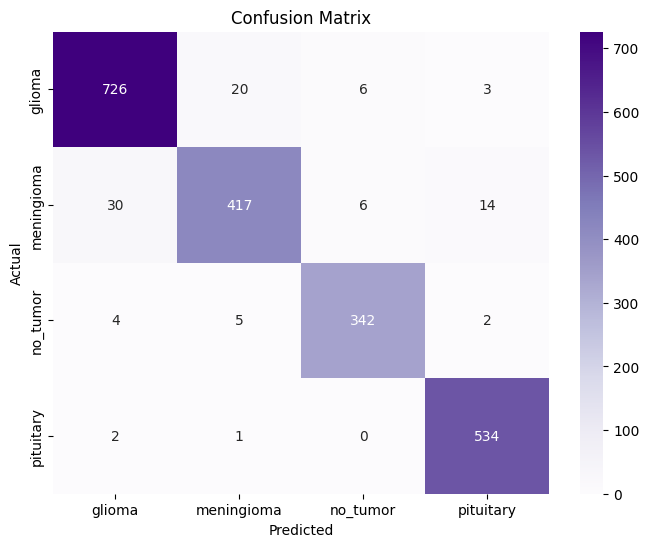

In [ ]:
# Compute the confusion matrix from true and predicted labels
cm = confusion_matrix(y_true, y_pred)

# Plotting with figure size and heat map labeling
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names,
            yticklabels=class_names)

# More labeling for clarity
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Confusion Matrix Analysis

From the plot we can see that it did I really good job at telling which was which but its definitly not perfect. The confusion matrix had no problem identifying no_tumor and Pituitary but mixed up Glioma and Meningoma with other things a lot.


Glioma - 721/755 ~ 95%

Meningioma - 394/467 ~ 84%

No_Tumor - 349/353 ~ 99%

Pituitary - 533/537 ~ 99%

As we can see by the percentages everything but Meningioma did really well while 84% isnt horrible for identifity cancer that is not a trust worthy statistic.

# Eliminating Bias With Test Evaluation

With a Confusion matrix the best evaluation is Test because its the only one that doesnt see the process that both Validation and Training see so now we do the same but with a test data split.

In [ ]:
# Now we do the same as we did earlier but add the Test split that doesn't see any of the training.
img_size = (224, 224)
batch_size = 32

# 80% train, 20% val+test
train_ds = tf.keras.utils.image_dataset_from_directory(
    root_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode="categorical"
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    root_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode="categorical"
)

# Split val + test in half
val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 10560 files belonging to 4 classes.
Using 8448 files for training.
Found 10560 files belonging to 4 classes.
Using 2112 files for validation.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [ ]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━

# Confusion Matrix on Test Set

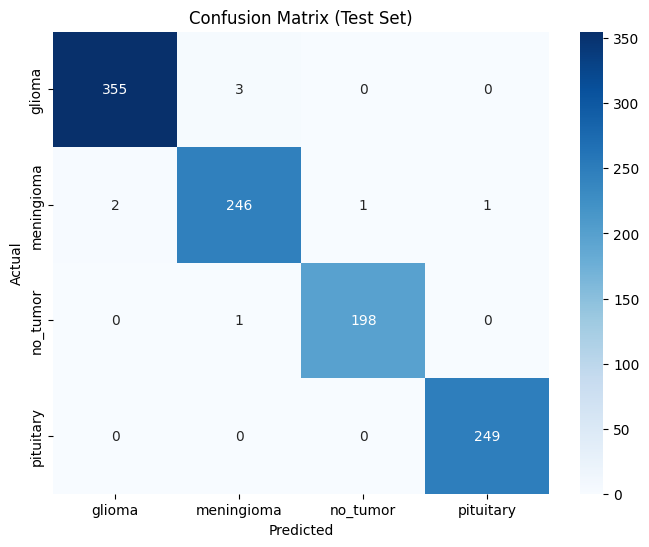

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Plotting Model Performance

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(class_names, labels=class_names)
plt.title("Accuracy of Tumor Type")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

In [ ]:
history.history


NameError: name 'history' is not defined